# Simple Model

This is a self-contained version where we used the classical way of calculating elo-ratings + logistic regression for prediction. We only used data from results.csv for this notebook.

## kagglehub dataset import
https://www.kaggle.com/datasets/martj42/international-football-results-from-1872-to-2017/data

In [60]:
import kagglehub
import os
import pandas as pd
import shutil

# import data with kagglehub
path = kagglehub.dataset_download("martj42/international-football-results-from-1872-to-2017")
print(path)
print(os.listdir(path))

# copy the freshly downloaded files into your project's data/raw folder
raw_dir = "data/raw"
os.makedirs(raw_dir, exist_ok=True)
for fname in ["results.csv", "shootouts.csv"]:
    shutil.copy(os.path.join(path, fname), os.path.join(raw_dir, fname))

C:\Users\ARW\.cache\kagglehub\datasets\martj42\international-football-results-from-1872-to-2017\versions\132
['former_names.csv', 'goalscorers.csv', 'results.csv', 'shootouts.csv']


In [61]:
# import the results.csv data into a pandas dataframe and filter for matches after 1993-01-01
df_results = pd.read_csv(os.path.join(path, "results.csv"))
df_results = df_results[df_results["date"] >= "1993-01-01"]
df_results.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
18708,1993-01-01,Ghana,Mali,1.0,1.0,Friendly,Libreville,Gabon,True
18709,1993-01-02,Gabon,Burkina Faso,1.0,1.0,Friendly,Libreville,Gabon,False
18710,1993-01-02,Kuwait,Lebanon,2.0,0.0,Friendly,Kuwait City,Kuwait,False
18711,1993-01-03,Burkina Faso,Mali,1.0,0.0,Friendly,Libreville,Gabon,True
18712,1993-01-03,Gabon,Ghana,2.0,3.0,Friendly,Libreville,Gabon,False


In [62]:
# number of tournament types in the dataset
df_results["tournament"].value_counts().head(50)

tournament
Friendly                                 10211
FIFA World Cup qualification              6821
UEFA Euro qualification                   1991
African Cup of Nations qualification      1745
UEFA Nations League                        658
AFC Asian Cup qualification                613
African Cup of Nations                     606
FIFA World Cup                             597
CFU Caribbean Cup qualification            453
CONCACAF Nations League                    422
Gold Cup                                   404
CECAFA Cup                                 383
Island Games                               368
COSAFA Cup                                 354
Copa América                               352
UEFA Euro                                  308
AFF Championship                           291
AFC Asian Cup                              282
Gulf Cup                                   234
CFU Caribbean Cup                          187
SAFF Cup                                   162
UN

In [63]:
# list of unique tournament types in the dataset
sorted(df_results["tournament"].unique())

['ABCS Tournament',
 'AFC Asian Cup',
 'AFC Asian Cup qualification',
 'AFC Challenge Cup',
 'AFC Challenge Cup qualification',
 'AFC Solidarity Cup',
 'AFF Championship',
 'AFF Championship qualification',
 'ASEAN Championship',
 'ASEAN Championship qualification',
 'African Cup of Nations',
 'African Cup of Nations qualification',
 'Afro-Asian Games',
 'Al Ain International Cup',
 'Amílcar Cabral Cup',
 'Arab Cup',
 'Arab Cup qualification',
 'Asian Games',
 'Atlantic Heritage Cup',
 'Baltic Cup',
 'Benedikt Fontana Cup',
 'CAFA Nations Cup',
 'CECAFA Cup',
 'CFU Caribbean Cup',
 'CFU Caribbean Cup qualification',
 'CONCACAF Nations League',
 'CONCACAF Nations League qualification',
 'CONCACAF Series',
 'CONIFA Africa Football Cup',
 'CONIFA Asia Cup',
 'CONIFA European Football Cup',
 'CONIFA South America Football Cup',
 'CONIFA World Cup qualification',
 'CONIFA World Football Cup',
 'CONIFA World Football Cup qualification',
 'CONMEBOL–UEFA Cup of Champions',
 'COSAFA Cup',
 'COS

In [64]:
# number of unique tournament types in the dataset
df_results["tournament"].nunique()

142

## build target variable

In [65]:
# convert to home score results
import numpy as np

df_results["result"] = np.where(df_results["home_score"] > df_results["away_score"], 2,   # home win
               np.where(df_results["home_score"] == df_results["away_score"], 1,  # draw
                0)) # home loss
print(df_results["result"].value_counts(normalize=True).mul(100).round(2)) # percentage of each result


result
2    48.55
0    28.14
1    23.32
Name: proportion, dtype: float64


In [66]:
# sorted chronologically

df_results["date"] = pd.to_datetime(df_results["date"])
df_results = df_results.sort_values("date").reset_index(drop=True)
df_results[["date","home_team","away_team", "result"]].head()

,date,home_team,away_team,result
0,1993-01-01,Ghana,Mali,1
1,1993-01-02,Gabon,Burkina Faso,1
2,1993-01-02,Kuwait,Lebanon,2
3,1993-01-03,Burkina Faso,Mali,2
4,1993-01-03,Gabon,Ghana,0


In [67]:
print(df_results["date"].min())
print(df_results["date"].max())

1993-01-01 00:00:00
2026-07-09 00:00:00


## elo calculation

We first calculate the ELO ratings from the kaggle dataset, using FIFA's SUM system based on match importance factor, elo scores before match, and resultant vs expected elo scores. In the end we want something like:

| date       | home_team | away_team | home_elo | away_elo | result |
| ---------- | --------- | --------- | -------- | -------- | ------ |
| 1950-07-16 | Brazil    | Uruguay   | 1832     | 1798     | loss   |


references: 
- https://digitalhub.fifa.com/m/f99da4f73212220/original/edbm045h0udbwkqew35a-pdf.pdf
- https://fifarankingcalculator.com/
- https://worldfootballrankings.com/methodology

In [68]:
# simple model first
INITIAL_ELO = 1500
from collections import defaultdict
ratings = defaultdict(lambda: 1500)
ratings["England"]

1500

Expected elo score:
$$E_A = 1 / {1+10^{(R_B-R_A)/400}}$$
$$E_B = 1 - E_A$$

Actual score: win=1, draw=0.5, loss=0.

Updated elo score:
$$R_A′=R_A + K (S_A − E_A)$$
$$R_B′=R_B + K (S_B - E_B)$$

In [69]:
K = 30 # initial K-factor
home_elos = [] # containers
away_elos = []

# iterate through each match
for _, row in df_results.iterrows():
    home = row["home_team"]
    away = row["away_team"]

    # calculate current ratings for home and away teams RA, RB
    home_rating = ratings[home]
    away_rating = ratings[away]

    # store PRE-MATCH ratings
    home_elos.append(home_rating)
    away_elos.append(away_rating)

    # apply formula to calculate EA, EB
    expected_home = 1 / (1 + 10 ** ((away_rating - home_rating) / 400))
    expected_away = 1 - expected_home

    # calculate actual result SA, SB
    if row["home_score"] > row["away_score"]:
        actual_home = 1
        actual_away = 0

    elif row["home_score"] < row["away_score"]:
        actual_home = 0
        actual_away = 1

    else:
        actual_home = 0.5
        actual_away = 0.5

    # updated RA', RB'
    ratings[home] = (home_rating + K * (actual_home - expected_home))
    ratings[away] = (away_rating + K * (actual_away - expected_away))


df_results["home_elo"] = home_elos
df_results["away_elo"] = away_elos

In [70]:
# check tail of the dataframe
df_results[["date", "home_team", "away_team", "home_elo", "away_elo"]].tail(10)

,date,home_team,away_team,home_elo,away_elo
30784,2026-07-03,Colombia,Ghana,1926.627707,1591.538439
30785,2026-07-04,Canada,Morocco,1797.140181,1913.100392
30786,2026-07-04,Paraguay,France,1784.487593,1989.398425
30787,2026-07-05,Mexico,England,1904.013181,1931.525438
30788,2026-07-05,Brazil,Norway,1952.730496,1838.211853
30789,2026-07-06,Argentina,Egypt,2046.719075,1766.080781
30790,2026-07-06,Switzerland,Colombia,1848.635938,1930.433782
30791,2026-07-06,Portugal,Spain,1938.448714,2023.894180
30792,2026-07-06,United States,Belgium,1818.312432,1868.276967
30793,2026-07-09,France,Morocco,1996.452356,1923.271959


## train logistic regression

count    30794.000000
mean        14.111900
std        172.288288
min       -971.809280
25%        -85.120124
50%         13.959205
75%        116.520449
max        946.844503
Name: elo_diff, dtype: float64


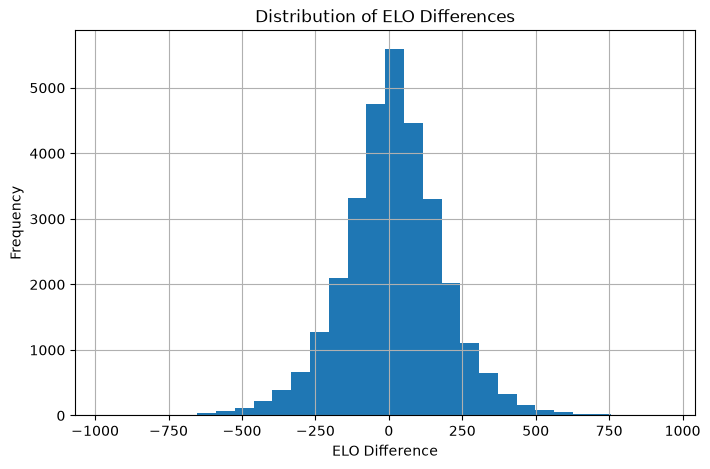

accuracy score = 0.598172025461074


In [71]:
df_results["elo_diff"] = (df_results["home_elo"] - df_results["away_elo"])
print(df_results["elo_diff"].describe())

import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.hist(df_results["elo_diff"], bins=30)
plt.xlabel("ELO Difference")
plt.ylabel("Frequency")
plt.title("Distribution of ELO Differences")
plt.grid(True)
plt.show()
# features
X = df_results[["elo_diff"]]

# targets
y = df_results["result"]

# train/test split:
"""
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = (
    train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42
    )
)
"""
# time-based split
train = df_results[df_results["date"] < "2020-01-01"]
test = df_results[df_results["date"] >= "2020-01-01"]
X_train = train[["elo_diff"]]
y_train = train["result"]
X_test = test[["elo_diff"]]
y_test = test["result"]

# logistic regression model
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000) # classifier for 3-class problems
model.fit(X_train, y_train) # fit the model to the training data

# get predictions labels, evaluate the model
from sklearn.metrics import accuracy_score
pred = model.predict(X_test)
print(f"accuracy score = {accuracy_score(y_test, pred)}")


In [72]:
# the loss function for logistic regression is the log loss function
from sklearn.metrics import log_loss
# these two metrics are what we compare against later models.
probs = model.predict_proba(X_test)
print(f"log loss = {log_loss(y_test, probs)}")

log loss = 0.8796155301089199


In [73]:
model.predict_proba([[0]])

c:\Users\ARW\anaconda3\envs\prediction\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([[0.25912525, 0.26700983, 0.47386492]])

In [74]:
model.predict_proba([[300]])

c:\Users\ARW\anaconda3\envs\prediction\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([[0.03225668, 0.1164398 , 0.85130352]])

c:\Users\ARW\anaconda3\envs\prediction\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


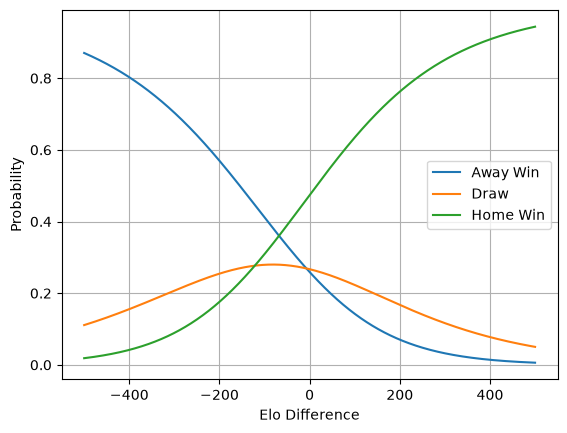

In [75]:
elo_range = np.linspace(-500, 500, 1000).reshape(-1, 1)

probs = model.predict_proba(elo_range)

plt.plot(elo_range, probs[:, 0], label="Away Win")
plt.plot(elo_range, probs[:, 1], label="Draw")
plt.plot(elo_range, probs[:, 2], label="Home Win")

plt.xlabel("Elo Difference")
plt.ylabel("Probability")
plt.legend()
plt.grid(True)
plt.show()

In [76]:
# save result as csv
df_results.to_csv("../data/processed/simple_model_results.csv", index=False)

In [77]:
# print top 10 teams by final ELO rating
final_ratings = sorted(ratings.items(), key=lambda x: x[1], reverse=True)
print("Top 10 Teams by Final ELO Rating:")
for team, rating in final_ratings[:10]:
    print(f"{team}: {rating:.2f}")

Top 10 Teams by Final ELO Rating:
Argentina: 2036.69
Spain: 2020.28
France: 1993.34
Brazil: 1947.96
Portugal: 1942.07
England: 1930.34
Colombia: 1926.97
Morocco: 1926.39
Netherlands: 1905.83
Mexico: 1905.20
